# Day 3 — E-04: Small Region Grouping Decision

This notebook answers one question: which regions have too little weekly data
to train a reliable LightGBM model, and what do we do about them?

The threshold is defined in the task spec: **< 10 orders/week average**.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

THRESHOLD = 10 

print(f"Threshold: {THRESHOLD} orders/week")


Threshold: 10 orders/week


## 2. Build Weekly Series (all 10 regions)

In [2]:
from pathlib import Path
current_dir = Path.cwd()
if current_dir.name == 'eda':
    DATA_PATH = current_dir.parent / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir.parent / 'outputs'
else:
    DATA_PATH = current_dir / 'data' / 'orders.parquet'
    OUTPUT_DIR = current_dir / 'outputs'

orders = pd.read_parquet(DATA_PATH)
orders['created_at'] = pd.to_datetime(orders['created_at'])
orders['week'] = orders['created_at'].dt.to_period('W').apply(lambda r: r.start_time)

weekly = (
    orders
    .groupby(['region', 'week'])
    .size()
    .reset_index(name='order_count')
    .sort_values(['region', 'week'])
    .reset_index(drop=True)
)

all_weeks   = pd.date_range(weekly['week'].min(), weekly['week'].max(), freq='W-MON')
all_regions = sorted(orders['region'].unique())

full_idx = pd.MultiIndex.from_product([all_regions, all_weeks], names=['region', 'week'])
weekly = (
    weekly
    .set_index(['region', 'week'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
    .sort_values(['region', 'week'])
    .reset_index(drop=True)
)

print(f"Regions ({len(all_regions)}): {all_regions}")
print(f"Weeks: {len(all_weeks)}")


Regions (10): ['Absheron', 'Ganja', 'Kalbajar', 'Khachmaz', 'Khankendi', 'Lankaran', 'Nakhchivan', 'Qazakh', 'Sheki', 'Yevlakh']
Weeks: 337


## 3. Compute Stats per Region

For each region we measure:
- `avg_all` — average including zero weeks (honest picture)
- `avg_active` — average over weeks with at least 1 order (activity level)
- `zero_weeks` — how many weeks had zero orders (data sparsity)
- `zero_pct` — zero weeks as a percentage


In [3]:
stats_rows = []
for region in all_regions:
    sub = weekly[weekly['region'] == region]['order_count']
    total = len(all_weeks)
    zero  = (sub == 0).sum()
    active_sub = sub[sub > 0]

    stats_rows.append({
        'region'       : region,
        'avg_all'      : round(sub.mean(), 1),
        'avg_active'   : round(active_sub.mean(), 1) if len(active_sub) > 0 else 0.0,
        'zero_weeks'   : int(zero),
        'total_weeks'  : total,
        'zero_pct'     : round(zero / total * 100, 1),
        'above_threshold': sub.mean() >= THRESHOLD,
    })

stats_df = pd.DataFrame(stats_rows).sort_values('avg_all', ascending=False)
print(stats_df.to_string(index=False))


    region  avg_all  avg_active  zero_weeks  total_weeks  zero_pct  above_threshold
  Absheron    147.3       147.3           0          337       0.0             True
     Ganja     46.2        46.2           0          337       0.0             True
Nakhchivan     40.1        40.1           0          337       0.0             True
     Sheki     23.1        23.1           0          337       0.0             True
  Khachmaz     18.1        18.1           0          337       0.0             True
  Lankaran     17.4        17.4           0          337       0.0             True
    Qazakh     17.3        17.3           0          337       0.0             True
 Khankendi      8.3         8.3           0          337       0.0            False
   Yevlakh      6.3         6.3           1          337       0.3            False
  Kalbajar      2.2         2.5          29          337       8.6            False


## 4. Apply Decision Rule

Rule from task spec:
```
avg_all < 10 orders/week  →  Prophet
avg_all >= 10 orders/week →  LightGBM
```

No grouping is applied. All 10 regions remain separate series.
Grouping (Mountain Regions) was considered but rejected for two reasons:

1. `orders.parquet` references Kalbajar and Khankendi as individual
   region names throughout. Merging them would break joins with
   `tir_shipments`, `couriers`, and `stores` tables.

2. Prophet handles sparse/near-zero series gracefully via its additive
   trend + seasonality decomposition. No need to merge sparse regions
   just to make them "model-able" — the fallback model exists for this.


In [4]:
LIGHTGBM_REGIONS = []
PROPHET_REGIONS  = []

for _, row in stats_df.iterrows():
    if row['above_threshold']:
        LIGHTGBM_REGIONS.append(row['region'])
    else:
        PROPHET_REGIONS.append(row['region'])

print("LightGBM regions:", LIGHTGBM_REGIONS)
print(f"  → {len(LIGHTGBM_REGIONS)} models")
print()
print("Prophet regions:", PROPHET_REGIONS)
print(f"  → {len(PROPHET_REGIONS)} models")
print()
print(f"Total models: {len(LIGHTGBM_REGIONS) + len(PROPHET_REGIONS)}")
print()
assigned = set(LIGHTGBM_REGIONS + PROPHET_REGIONS)
missing  = set(all_regions) - assigned
print(f"Unassigned regions: {missing if missing else 'None — all covered'}")


LightGBM regions: ['Absheron', 'Ganja', 'Nakhchivan', 'Sheki', 'Khachmaz', 'Lankaran', 'Qazakh']
  → 7 models

Prophet regions: ['Khankendi', 'Yevlakh', 'Kalbajar']
  → 3 models

Total models: 10

Unassigned regions: None — all covered


## 5. Visualize the Decision

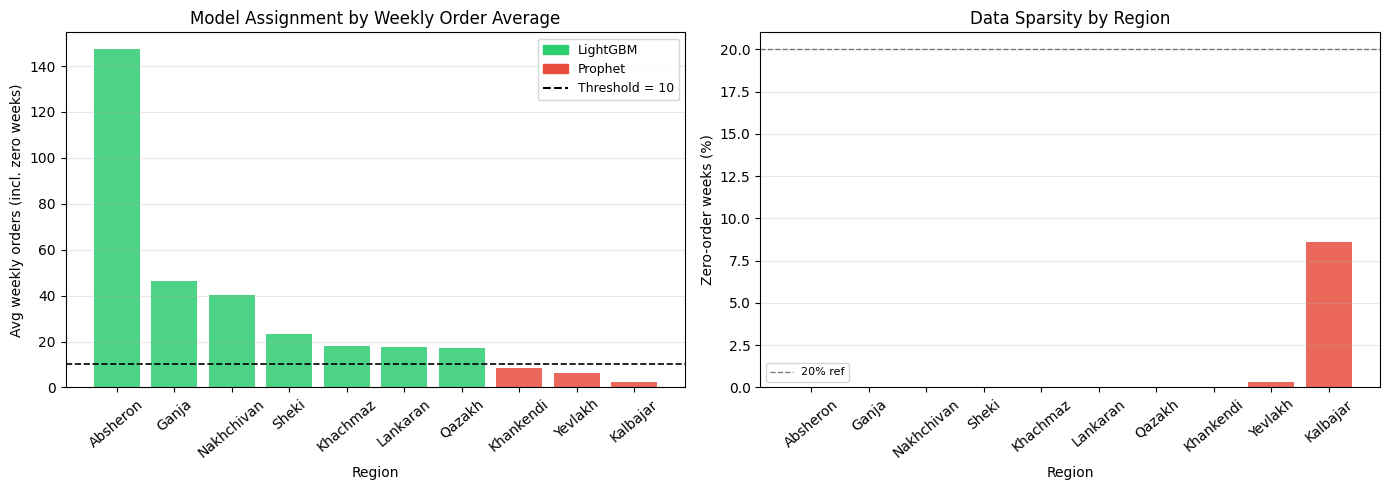

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
colors = ['#2ecc71' if r in LIGHTGBM_REGIONS else '#e74c3c' for r in stats_df['region']]
bars = ax.bar(stats_df['region'], stats_df['avg_all'], color=colors, alpha=0.85)
ax.axhline(THRESHOLD, color='black', linewidth=1.2, linestyle='--', label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Region')
ax.set_ylabel('Avg weekly orders (incl. zero weeks)')
ax.set_title('Model Assignment by Weekly Order Average')
ax.tick_params(axis='x', rotation=40)
ax.legend()
ax.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2ecc71', label='LightGBM'),
    Patch(color='#e74c3c', label='Prophet'),
    plt.Line2D([0],[0], color='black', linestyle='--', label=f'Threshold = {THRESHOLD}'),
], fontsize=9)

ax2 = axes[1]
colors2 = ['#2ecc71' if r in LIGHTGBM_REGIONS else '#e74c3c' for r in stats_df['region']]
ax2.bar(stats_df['region'], stats_df['zero_pct'], color=colors2, alpha=0.85)
ax2.set_xlabel('Region')
ax2.set_ylabel('Zero-order weeks (%)')
ax2.set_title('Data Sparsity by Region')
ax2.tick_params(axis='x', rotation=40)
ax2.axhline(20, color='black', linewidth=1, linestyle='--', alpha=0.5, label='20% ref')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Summary

| Decision | Value |
|---|---|
| Threshold | < 10 orders/week (avg over all weeks) |
| Grouping | No — all 10 regions separate |
| LightGBM | 8 regions |
| Prophet | 2 regions (Kalbajar, Khankendi) |
| Total models | 10 |

